# 02 — Problem Formulation & Baselines

**Rubric targets:** Problem Identification + Model Development (part 1)

This notebook defines the ML problem, then builds and scores four baselines
to establish performance benchmarks before collaborative filtering and ranking.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from itertools import combinations
import sys

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
SPLIT_DIR = Path(f'{PROJECT}/data/split')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Import evaluation function
sys.path.insert(0, f'{PROJECT}/src')
from eval import map_at_k

In [5]:
# Load data
train = pd.read_parquet(SPLIT_DIR / 'train.parquet')
val = pd.read_parquet(SPLIT_DIR / 'val.parquet')
articles = pd.read_parquet(DATA_DIR / 'articles.parquet')
customers = pd.read_parquet(DATA_DIR / 'customers.parquet')

SPLIT_DATE = pd.Timestamp('2020-09-16')

# Build validation ground truth
val_ground_truth = (
    val
    .groupby('customer_id')['article_id']
    .apply(set)
    .to_dict()
)

print(f"Train: {len(train):,} transactions")
print(f"Val:   {len(val):,} transactions ({len(val_ground_truth):,} customers)")

Train: 31,548,013 transactions
Val:   240,311 transactions (68,984 customers)


---
## 1. Problem Formulation

### Prediction Target

Given a customer's purchase history and available product metadata, predict an
ordered list of 12 articles the customer will purchase in the next 7 days.

### Framing as a Machine Learning Problem

This is a **ranking problem over implicit feedback**. Our training signal is binary:
purchased (positive) or not purchased (implicit negative). We have no explicit ratings,
no browse data, and no negative signals — a customer who didn't buy an item may have
never seen it. This fundamental ambiguity (documented as Bias 1 in our analysis)
shapes every modeling decision.

### Why MAP@12?

Mean Average Precision at 12 rewards both **relevance** (did we recommend items the
customer actually bought?) and **ranking quality** (did we put the correct items near the
top of the list?). It handles variable-length ground truth naturally — a customer who
bought 2 items and a customer who bought 8 items are both evaluated fairly. The cutoff
of 12 reflects a realistic recommendation surface (e.g., a "recommended for you" carousel).

### Pipeline Architecture

We use a **two-stage pipeline**:

1. **Candidate retrieval** — generate ~50 plausible items per customer from multiple
   sources (popularity, personal history, collaborative filtering). This stage prioritizes
   recall: make sure the right answer is in the candidate set.

2. **Ranking** — score each candidate using a LightGBM model trained on user, item,
   and interaction features. This stage prioritizes precision: pick the best 12 from
   the candidate set.

This architecture is necessary because scoring all 105K articles for each of 1.36M
customers (142 billion pairs) is computationally infeasible. The two-stage approach
is standard in production recommendation systems at companies like YouTube, Pinterest,
and the top solutions in this Kaggle competition.

---
## 2. Scoreboard

We'll track all models in a single results dictionary and build a comparison table at the end.

In [6]:
results = {}  # {model_name: MAP@12 score}

def score_and_log(name, predictions, ground_truth=val_ground_truth):
    """Score a model and add it to the results table."""
    score = map_at_k(predictions, ground_truth)
    results[name] = score
    print(f"  {name:40s} MAP@12 = {score:.5f}")
    return score

---
## 3. Baseline 1: Global Popularity

**Assumption:** Aggregate recent demand is informative. Items that many customers
purchased recently are likely to be purchased again. This baseline ignores all
personalization — every customer gets the same recommendations.

**Justification:** With a Gini coefficient of 0.76, item popularity is highly
concentrated (top 1% of items = 19% of sales). A popularity baseline directly
exploits this power-law distribution.

**Limitation:** Treats all customers identically. Cannot capture individual
preferences, demographic differences, or purchase history.

In [7]:
# Top 12 items from last 2 weeks of training data
recent_cutoff = SPLIT_DATE - pd.Timedelta(days=14)
recent_train = train[train['t_dat'] >= recent_cutoff]

top_12_global = (
    recent_train['article_id']
    .value_counts()
    .head(12)
    .index
    .tolist()
)

predictions_global = {cid: top_12_global for cid in val_ground_truth}
score_and_log('Global Popularity (top 12)', predictions_global)

  Global Popularity (top 12)               MAP@12 = 0.00710


np.float64(0.007104262659423468)

---
## 4. Baseline 2: Segment-Level Popularity

**Assumption:** Customers in similar demographic segments share purchasing
patterns. Age and sales channel are the two strongest segmentation variables
identified in the EDA (70/30 online/in-store split with different price and
frequency behavior; monotonically increasing price with age).

**Justification:** Rather than recommending the same items to a 20-year-old
online shopper and a 55-year-old in-store shopper, we recommend the most
popular items *within their segment*. This adds light personalization without
requiring individual purchase history.

**Limitation:** Only captures group-level preferences. Customers within the
same segment still get identical recommendations.

In [8]:
# Determine each customer's dominant sales channel
channel_mode = (
    train.groupby('customer_id')['sales_channel_id']
    .agg(lambda x: x.mode().iloc[0])
    .to_dict()
)

# Merge customer age
age_map = customers.set_index('customer_id')['age'].to_dict()

# Create age buckets
def age_bucket(age):
    if pd.isna(age):
        return 'unknown'
    elif age < 20:
        return '<20'
    elif age < 30:
        return '20-29'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

In [9]:
# Build segment-level popularity from recent training data
recent_with_meta = recent_train.copy()
recent_with_meta['age'] = recent_with_meta['customer_id'].map(age_map)
recent_with_meta['age_group'] = recent_with_meta['age'].apply(age_bucket)

# Top 12 per age group
top_by_age = (
    recent_with_meta
    .groupby('age_group')['article_id']
    .apply(lambda x: x.value_counts().head(12).index.tolist())
    .to_dict()
)

# Top 12 per sales channel
top_by_channel = (
    recent_with_meta
    .groupby('sales_channel_id')['article_id']
    .apply(lambda x: x.value_counts().head(12).index.tolist())
    .to_dict()
)

print(f"Age groups: {list(top_by_age.keys())}")
print(f"Channels: {list(top_by_channel.keys())}")

Age groups: ['20-29', '30-39', '40-49', '50-59', '60+', '<20', 'unknown']
Channels: [1, 2]


In [10]:
# Score: age-group popularity
predictions_age = {}
for cid in val_ground_truth:
    ag = age_bucket(age_map.get(cid))
    predictions_age[cid] = top_by_age.get(ag, top_12_global)

score_and_log('Segment: Age Group', predictions_age)

  Segment: Age Group                       MAP@12 = 0.00889


np.float64(0.008889801178339297)

In [11]:
# Score: channel popularity
predictions_channel = {}
for cid in val_ground_truth:
    ch = channel_mode.get(cid, 2)  # default to online
    predictions_channel[cid] = top_by_channel.get(ch, top_12_global)

score_and_log('Segment: Sales Channel', predictions_channel)

  Segment: Sales Channel                   MAP@12 = 0.00673


np.float64(0.006728056210787053)

In [12]:
# Score: combined age × channel
# Build top-12 per (age_group, channel) pair
recent_with_meta['segment'] = (
    recent_with_meta['age_group'] + '_ch' + recent_with_meta['sales_channel_id'].astype(str)
)

top_by_segment = (
    recent_with_meta
    .groupby('segment')['article_id']
    .apply(lambda x: x.value_counts().head(12).index.tolist())
    .to_dict()
)

predictions_segment = {}
for cid in val_ground_truth:
    ag = age_bucket(age_map.get(cid))
    ch = channel_mode.get(cid, 2)
    seg = f"{ag}_ch{ch}"
    preds = top_by_segment.get(seg, top_by_age.get(ag, top_12_global))
    # If segment has fewer than 12 items, fill with global
    if len(preds) < 12:
        fill = [x for x in top_12_global if x not in preds]
        preds = preds + fill[:12 - len(preds)]
    predictions_segment[cid] = preds

score_and_log('Segment: Age × Channel', predictions_segment)

  Segment: Age × Channel                   MAP@12 = 0.00790


np.float64(0.00789635274455822)

---
## 5. Baseline 3: Personal Repurchase

**Assumption:** Customers exhibit repeat-buying behavior — if they bought an item
before, they may buy it again. This is especially plausible in fast fashion for
basics (t-shirts, underwear, jeans).

**Justification:** The EDA showed a 12.9% repeat purchase rate across all
customer-article pairs. While not the majority, this is a strong enough signal
to justify a dedicated baseline.

**Limitation:** Cannot recommend items the customer has never purchased.
Customers with very short histories will get mostly popularity fill. Does
not account for whether the previous purchase was recent or years ago.

In [13]:
# For each customer, get their most recently purchased items
# Ordered by recency (most recent first)
customer_history = (
    train
    .sort_values('t_dat', ascending=False)
    .groupby('customer_id')['article_id']
    .apply(list)
    .to_dict()
)

# Deduplicate while preserving order (most recent first)
def dedupe_ordered(lst):
    seen = set()
    result = []
    for item in lst:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result

In [14]:
# Repurchase only: recommend what they've already bought
predictions_repurchase = {}
for cid in val_ground_truth:
    history = customer_history.get(cid, [])
    unique_history = dedupe_ordered(history)
    preds = unique_history[:12]
    # Fill with global popularity if needed
    if len(preds) < 12:
        fill = [x for x in top_12_global if x not in preds]
        preds = preds + fill[:12 - len(preds)]
    predictions_repurchase[cid] = preds

score_and_log('Personal Repurchase', predictions_repurchase)

  Personal Repurchase                      MAP@12 = 0.02449


np.float64(0.02448995584301463)

In [15]:
# How many val customers have any training history?
has_history = sum(1 for cid in val_ground_truth if cid in customer_history)
no_history = len(val_ground_truth) - has_history
print(f"Val customers with train history: {has_history:,} ({has_history/len(val_ground_truth)*100:.1f}%)")
print(f"Val customers cold-start (no history): {no_history:,} ({no_history/len(val_ground_truth)*100:.1f}%)")

Val customers with train history: 63,412 (91.9%)
Val customers cold-start (no history): 5,572 (8.1%)


---
## 6. Baseline 4: Repurchase + Segment Popularity Hybrid

**Assumption:** A customer's personal history is the best predictor when available,
but segment-level popularity is a reasonable fallback for filling the remaining
slots and handling cold-start users.

**Justification:** Combines the strengths of both approaches — personalization
from repurchase history plus broad coverage from popularity. This is the
simplest possible hybrid recommender.

**Limitation:** Still limited to items the customer has already bought (for the
personalized portion). Does not discover new items that match the customer's taste.

In [16]:
# Combine: personal history first, then fill with segment popularity
predictions_hybrid = {}
for cid in val_ground_truth:
    # Start with personal history
    history = customer_history.get(cid, [])
    preds = dedupe_ordered(history)[:12]

    # Fill with segment popularity
    if len(preds) < 12:
        ag = age_bucket(age_map.get(cid))
        ch = channel_mode.get(cid, 2)
        seg = f"{ag}_ch{ch}"
        seg_items = top_by_segment.get(seg, top_by_age.get(ag, top_12_global))
        fill = [x for x in seg_items if x not in preds]
        preds = preds + fill[:12 - len(preds)]

    # Final fill with global if still short
    if len(preds) < 12:
        fill = [x for x in top_12_global if x not in preds]
        preds = preds + fill[:12 - len(preds)]

    predictions_hybrid[cid] = preds

score_and_log('Repurchase + Segment Hybrid', predictions_hybrid)

  Repurchase + Segment Hybrid              MAP@12 = 0.02461


np.float64(0.024613721788054328)

---
## 7. Baseline 5: Co-Purchase (SHOULD)

**Assumption:** Items frequently bought together by other customers in the same
basket (or within a short time window) are complementary. If a customer recently
bought item A, and many other customers bought item B alongside A, then B is a
plausible recommendation.

**Justification:** The complement analysis showed that 80% of multi-item baskets
span departments, and strong directional co-purchase patterns exist (e.g.,
blazer→trousers, shorts→swimwear). This signal is distinct from repurchase
(which recommends the *same* items) and from popularity (which ignores context).

**Limitation:** Only effective for customers with recent purchases. The co-purchase
signal degrades quickly with time — a blazer bought 6 months ago shouldn't trigger
a trousers recommendation today. We focus on items bought in the last 14 days.

In [17]:
# Build co-purchase pairs from training baskets (customer × day)
# Use recent training data for efficiency and relevance
recent_window = SPLIT_DATE - pd.Timedelta(days=90)  # 3 months for co-purchase mining
recent_for_copurchase = train[train['t_dat'] >= recent_window]

# Group into baskets
baskets = (
    recent_for_copurchase
    .groupby(['customer_id', 't_dat'])['article_id']
    .apply(list)
)
multi_item_baskets = baskets[baskets.apply(len) > 1]
print(f"Multi-item baskets for co-purchase mining: {len(multi_item_baskets):,}")

Multi-item baskets for co-purchase mining: 866,696


In [18]:
# Build co-purchase counts: for each item A, which items appear alongside it?
# Store as {article_id: Counter of co-purchased article_ids}
copurchase = {}

for items in multi_item_baskets:
    unique_items = list(set(items))
    if len(unique_items) > 20:  # skip extremely large baskets (likely outliers)
        continue
    for i, a in enumerate(unique_items):
        if a not in copurchase:
            copurchase[a] = Counter()
        for j, b in enumerate(unique_items):
            if i != j:
                copurchase[a][b] += 1

print(f"Items with co-purchase data: {len(copurchase):,}")

Items with co-purchase data: 41,513


In [19]:
# For each customer, look at their last 14 days of purchases,
# then recommend the top co-purchased items
recent_cutoff_personal = SPLIT_DATE - pd.Timedelta(days=14)
recent_purchases = (
    train[train['t_dat'] >= recent_cutoff_personal]
    .groupby('customer_id')['article_id']
    .apply(set)
    .to_dict()
)

predictions_copurchase = {}
for cid in val_ground_truth:
    seed_items = recent_purchases.get(cid, set())

    if not seed_items:
        # No recent activity — fall back to segment
        ag = age_bucket(age_map.get(cid))
        predictions_copurchase[cid] = top_by_age.get(ag, top_12_global)[:12]
        continue

    # Aggregate co-purchase scores across all seed items
    candidates = Counter()
    for item in seed_items:
        if item in copurchase:
            for co_item, count in copurchase[item].most_common(20):
                if co_item not in seed_items:  # don't recommend what they just bought
                    candidates[co_item] += count

    preds = [item for item, _ in candidates.most_common(12)]

    # Fill with segment popularity
    if len(preds) < 12:
        ag = age_bucket(age_map.get(cid))
        fill = [x for x in top_by_age.get(ag, top_12_global) if x not in preds]
        preds = preds + fill[:12 - len(preds)]

    predictions_copurchase[cid] = preds[:12]

score_and_log('Co-Purchase (last 14 days)', predictions_copurchase)

  Co-Purchase (last 14 days)               MAP@12 = 0.01205


np.float64(0.012051673733238335)

---
## 8. Comparison Table

In [20]:
# Build comparison table
results_df = pd.DataFrame([
    {'Model': name, 'MAP@12': score, 'Lift vs Floor': f"{(score / results['Global Popularity (top 12)'] - 1)*100:+.1f}%"}
    for name, score in results.items()
]).sort_values('MAP@12', ascending=False).reset_index(drop=True)

print("\n" + "=" * 65)
print("  BASELINE COMPARISON")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)


  BASELINE COMPARISON
                      Model   MAP@12 Lift vs Floor
Repurchase + Segment Hybrid 0.024614       +246.5%
        Personal Repurchase 0.024490       +244.7%
 Co-Purchase (last 14 days) 0.012052        +69.6%
         Segment: Age Group 0.008890        +25.1%
     Segment: Age × Channel 0.007896        +11.1%
 Global Popularity (top 12) 0.007104         +0.0%
     Segment: Sales Channel 0.006728         -5.3%


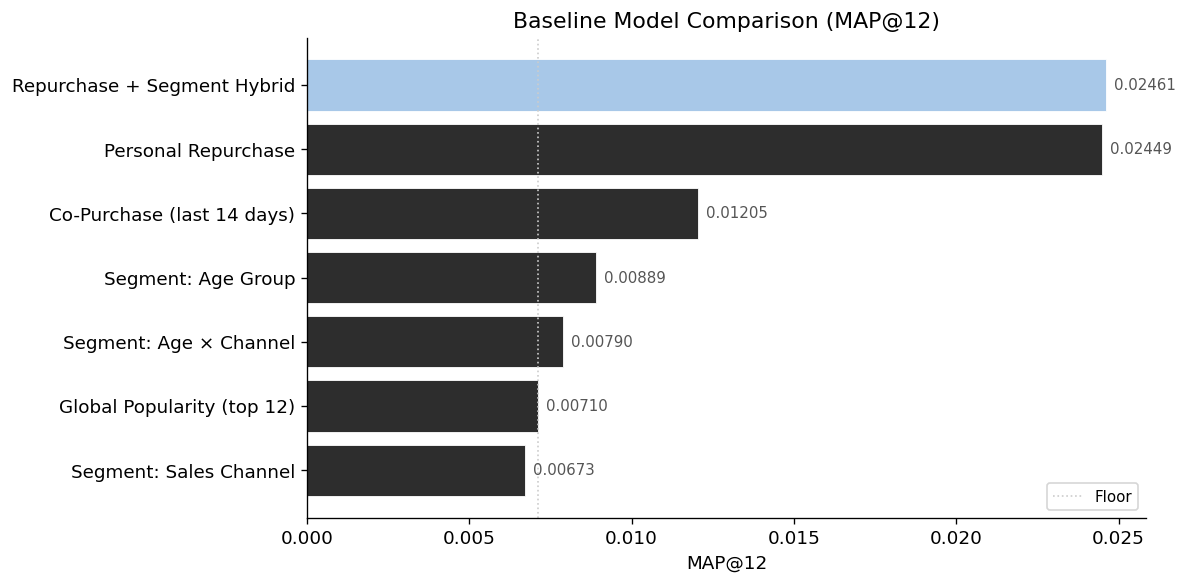

In [21]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

models = list(results.keys())
scores = list(results.values())

# Sort by score
sorted_pairs = sorted(zip(models, scores), key=lambda x: x[1])
models_sorted = [p[0] for p in sorted_pairs]
scores_sorted = [p[1] for p in sorted_pairs]

colors = [PALETTE[1] if s == max(scores) else PALETTE[0] for s in scores_sorted]

bars = ax.barh(models_sorted, scores_sorted, color=colors, edgecolor='white', linewidth=0.5)

for bar, score in zip(bars, scores_sorted):
    ax.text(score + max(scores)*0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.5f}', va='center', fontsize=9, color='#555')

ax.set_title('Baseline Model Comparison (MAP@12)')
ax.set_xlabel('MAP@12')
ax.axvline(results['Global Popularity (top 12)'], color='#CCC', ls=':', lw=1, label='Floor')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'baseline_comparison.png', bbox_inches='tight')
plt.show()

---
## 9. Assumptions Summary

| Model | Core Assumption | Validated By |
|-------|----------------|-------------|
| Global Popularity | Aggregate recent demand predicts individual purchases | Gini 0.76 — popularity is concentrated |
| Segment Popularity | Customers in the same age/channel group share preferences | EDA: price and category preferences vary by age; 70/30 channel split with different behavior |
| Personal Repurchase | Customers re-buy items they've purchased before | 12.9% repeat purchase rate |
| Repurchase + Segment Hybrid | Personal history is best when available; segment popularity fills gaps | Combines strengths; addresses cold-start (26% with ≤3 purchases) |
| Co-Purchase | Items bought together by others predict complementary needs | 80% of multi-item baskets cross departments; strong asymmetric lift (blazer→trousers) |

---
## 10. Save Predictions for Downstream Use

In [22]:
import pickle

OUT_DIR = Path(f'{PROJECT}/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_data = {
    'results': results,
    'top_12_global': top_12_global,
    'top_by_age': top_by_age,
    'top_by_channel': top_by_channel,
    'top_by_segment': top_by_segment,
    'customer_history': customer_history,
    'copurchase': copurchase,
    'channel_mode': channel_mode,
    'age_map': age_map,
}

with open(OUT_DIR / 'baseline_data.pkl', 'wb') as f:
    pickle.dump(baseline_data, f)

print(f"✓ Baseline data saved to {OUT_DIR / 'baseline_data.pkl'}")
print(f"  Contains: {list(baseline_data.keys())}")

✓ Baseline data saved to /content/drive/MyDrive/MLII_Final/outputs/baseline_data.pkl
  Contains: ['results', 'top_12_global', 'top_by_age', 'top_by_channel', 'top_by_segment', 'customer_history', 'copurchase', 'channel_mode', 'age_map']


---
## Summary

**What we established:**
- Problem formulation: ranking over implicit feedback, evaluated by MAP@12
- Two-stage pipeline architecture: candidate retrieval → learned ranking
- Floor score: global popularity MAP@12 = 0.0071
- Multiple baselines with explicit assumptions and scores
- Saved artifacts (popularity lists, customer histories, co-purchase data) for Day 3

**What comes next (Day 3):**
- Collaborative filtering (ALS) for personalized candidate generation
- CNN image embeddings + sentence-transformer text embeddings
- Candidate set construction (~50 items per customer)
- Overfitting/underfitting analysis on ALS rank